In [2]:
# Adapted from Anthropic Claude API Course
# Modified and extended for learning and experimentation

### Environmental Set up

In [1]:
# Install dependencies
%pip install anthropic python-dotenv

You should consider upgrading via the '/Users/upasanaghosh/ml-dev-workspace/building_with_claude_api/.buildingWithClaudeAPI/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load env variables
from dotenv import load_dotenv
import os

print("API key loaded:", load_dotenv())

API key loaded: True


In [3]:
# Create API client
from anthropic import Anthropic

client = Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
model = "claude-sonnet-4-0"

### Helper Functions

In [4]:
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)

def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)

# Response Streaming

When building chat applications with Claude, there's a significant user experience challenge: responses can take 10-30 seconds to generate, leaving users staring at a loading spinner. With streaming enabled, Claude immediately sends back an initial response indicating it has received your request and is starting to generate text. Then you receive a series of events, each containing a small piece of the overall response.

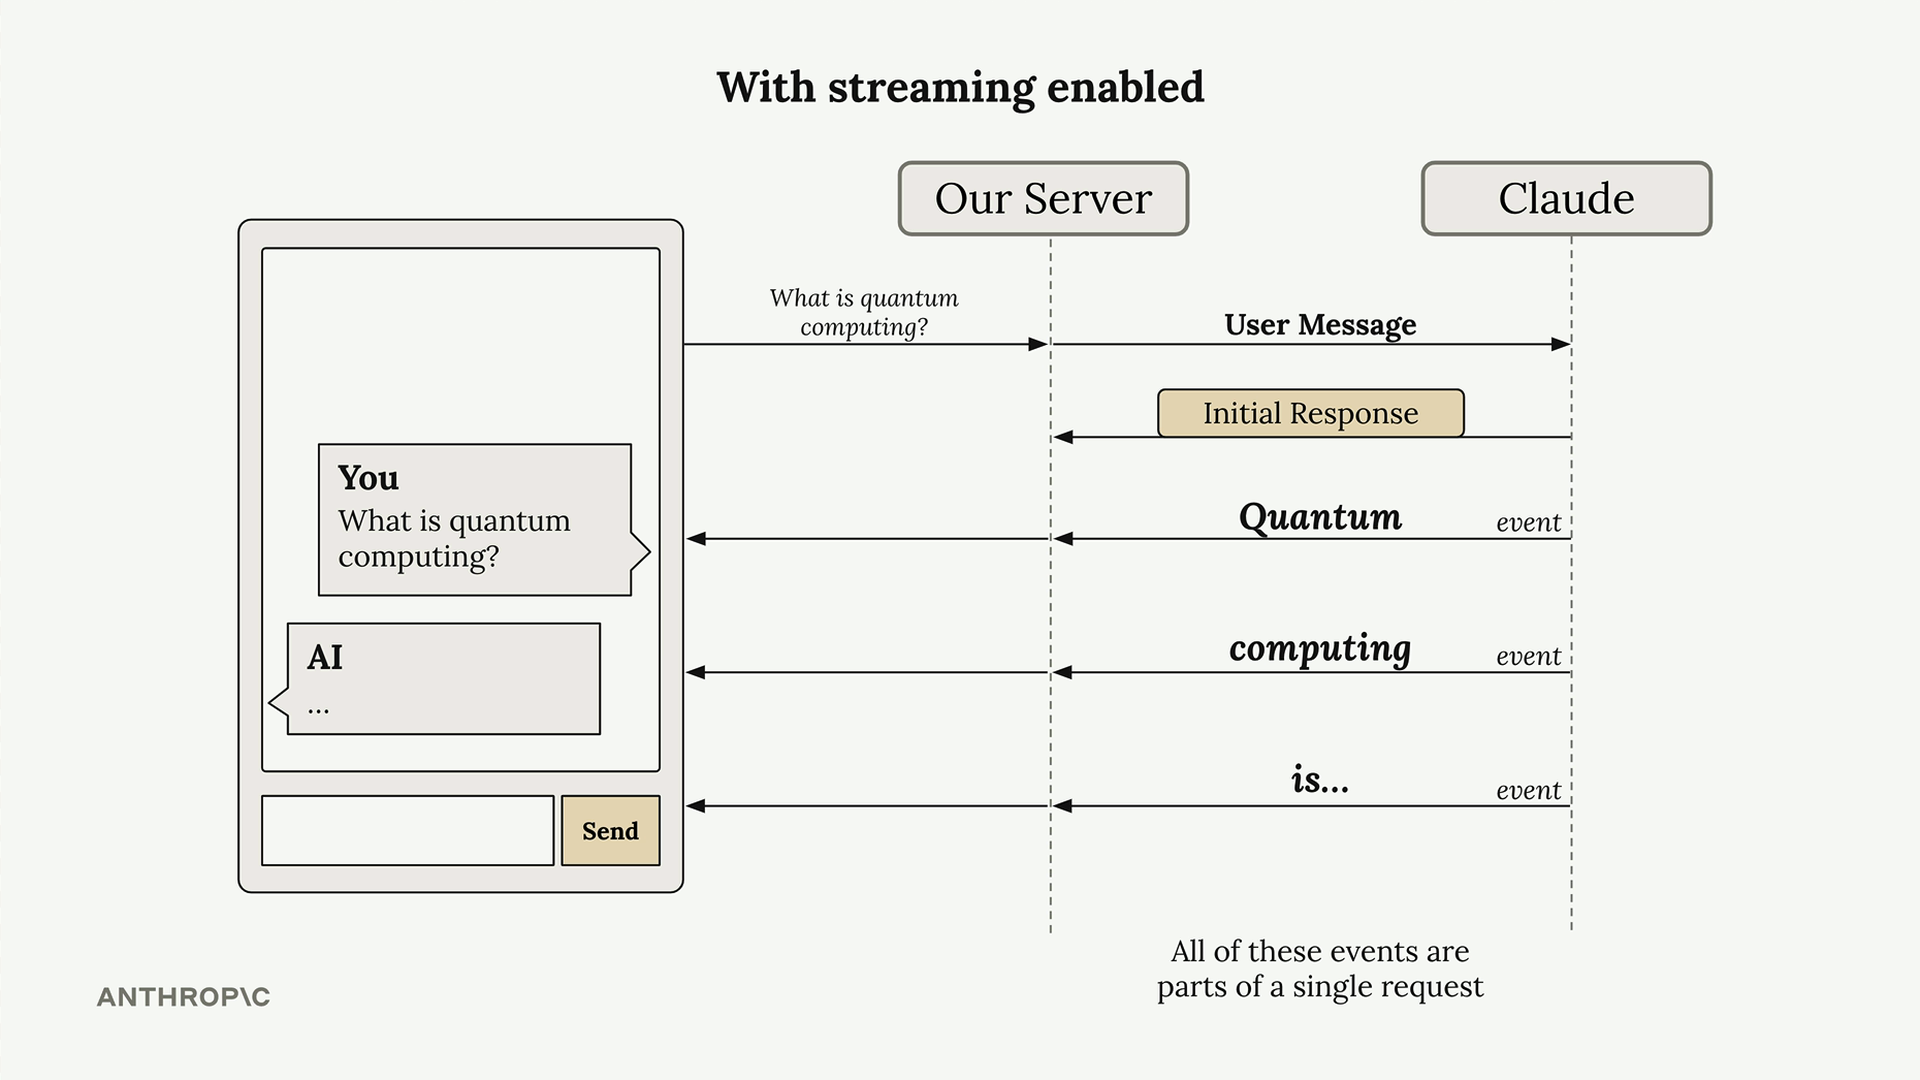

In [6]:
messages = []
add_user_message(messages, "Write a 1 sentence description of a fake database")

stream = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    stream=True
)

for event in stream:
    print(event)

RawMessageStartEvent(message=Message(id='msg_01SGLEXhuW366ZjAjeuPju1c', container=None, content=[], model='claude-sonnet-4-20250514', role='assistant', stop_reason=None, stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=18, output_tokens=1, server_tool_use=None, service_tier='standard'), stop_details=None), type='message_start')
RawContentBlockStartEvent(content_block=TextBlock(citations=None, text='', type='text'), index=0, type='content_block_start')
RawContentBlockDeltaEvent(delta=TextDelta(text='**', type='text_delta'), index=0, type='content_block_delta')
RawContentBlockDeltaEvent(delta=TextDelta(text='FakeDB** is a synthetic database containing fabricated customer records, transaction histories, and product invent', type='text_delta'), index=0, type='content_block_delta')
RawContentBlockDeltaEve

## Understanding Stream Events

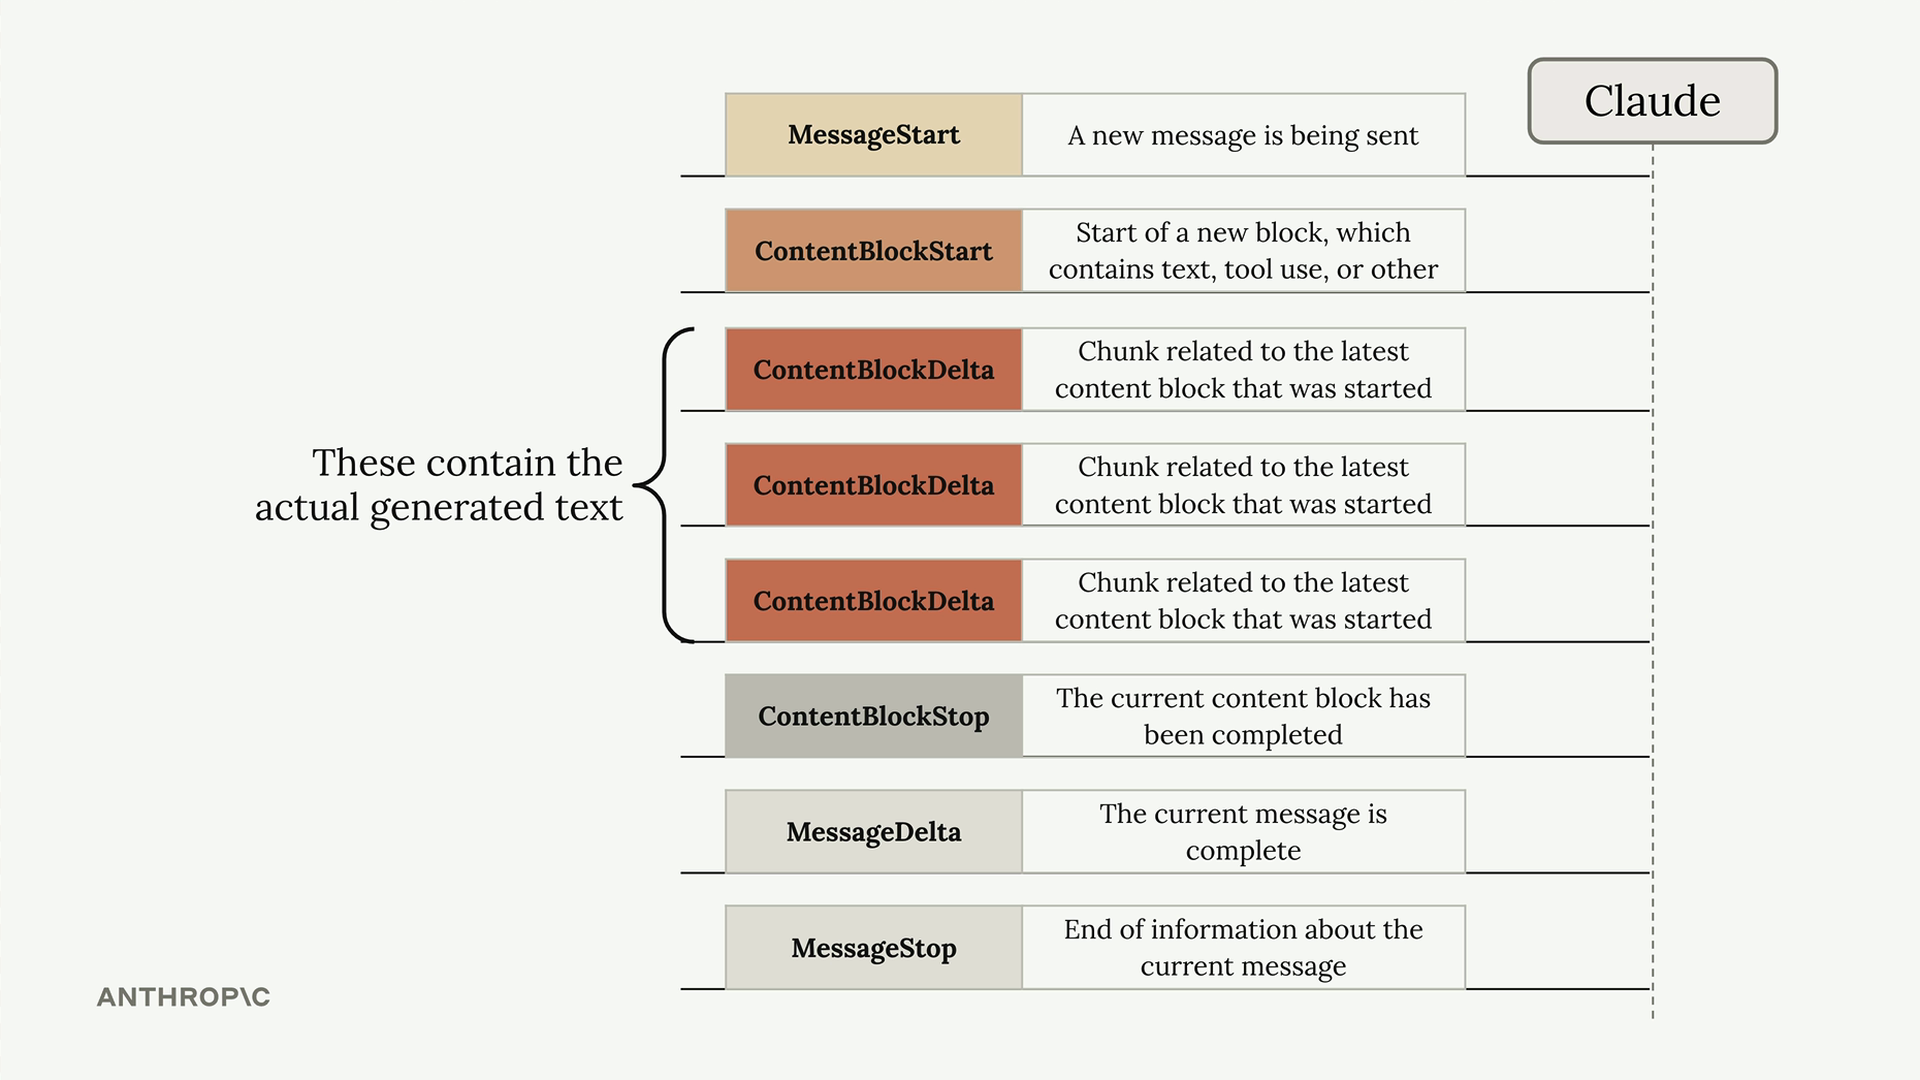

In [ ]:
# Rather than manually parsing events, use the SDK's simplified streaming interface 
# that extracts just the text content in chunks as they arrive.
with client.messages.stream(
    model=model,
    max_tokens=1000,
    messages=messages
) as stream:
    for text in stream.text_stream:
        print(text, end="")

InventoryPro is a comprehensive database system that tracks product stock levels, supplier information, and sales transactions for retail businesses across multiple store locations.

In [8]:
# To get the complete message, use the SDK's get_final_message function after the stream finishes
with client.messages.stream(
    model=model,
    max_tokens=1000,
    messages=messages
) as stream:
    for text in stream.text_stream:
        # Send each chunk to your client
        pass
    
    # Get the complete message for database storage
    final_message = stream.get_final_message()

In [18]:
final_message
#final_message.content[0].text

ParsedMessage(id='msg_0144TFisq5XACQgU9158nGuN', container=None, content=[ParsedTextBlock(citations=None, text='CloudSync Enterprise Database is a revolutionary NoSQL document store that uses quantum-encrypted blockchain technology to automatically synchronize data across multiple dimensions while maintaining ACID compliance through its proprietary neural network indexing system.', type='text', parsed_output=None)], model='claude-sonnet-4-20250514', role='assistant', stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=18, output_tokens=44, server_tool_use=None, service_tier='standard'), stop_details=None)